/tmp/ipython-input-259/414337601.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=stats, x='Object_Type', y='Count', palette='viridis')


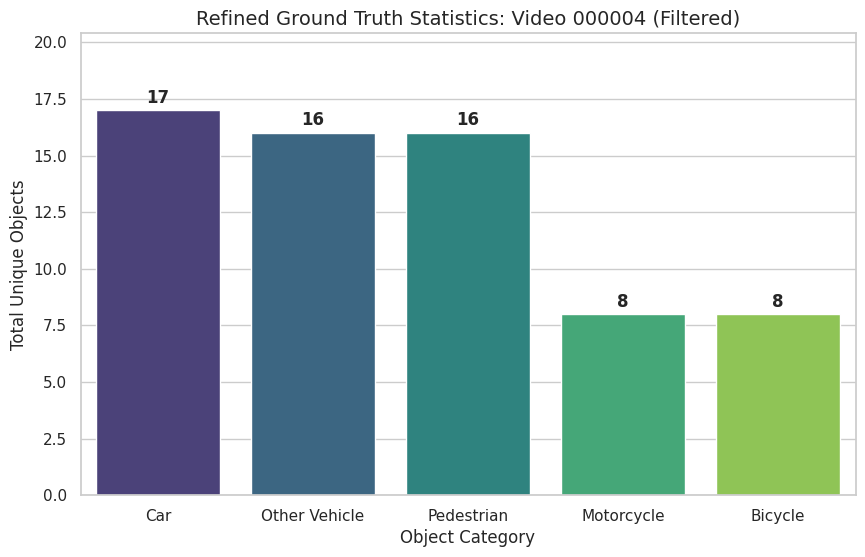

成功过滤并解析！共提取到 65 个交通相关标注对象。


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. 设定你的真实文件路径
file_path = '/content/VIRAT_S_000004.viratdata.objects.txt'

# 定义官方类别映射 (1-5类)
type_mapping = {
    1: 'Pedestrian',
    2: 'Car',
    3: 'Other Vehicle',
    4: 'Bicycle',
    5: 'Motorcycle'
}

if os.path.exists(file_path):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                try:
                    obj_type = int(parts[4])
                    # 关键修改：只保留定义过的 1-5 类，其余过滤掉
                    if obj_type in type_mapping:
                        data.append(type_mapping[obj_type])
                except ValueError:
                    continue

    # 2. 转换为 DataFrame 并统计
    df_real = pd.DataFrame(data, columns=['Object_Type'])

    # 如果数据为空的预警
    if df_real.empty:
        print("警告：解析后未发现 1-5 类目标，请检查文件格式。")
    else:
        stats = df_real['Object_Type'].value_counts().reset_index()
        stats.columns = ['Object_Type', 'Count']

        # 3. 绘制精简后的柱状图
        plt.figure(figsize=(10, 6))
        sns.set_theme(style="whitegrid")
        # 使用更专业的颜色方案
        ax = sns.barplot(data=stats, x='Object_Type', y='Count', palette='viridis')

        # 添加清晰的数值标注
        for p in ax.patches:
            ax.annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 9),
                       textcoords='offset points',
                       fontsize=12, fontweight='bold')

        plt.title('Refined Ground Truth Statistics: Video 000004 (Filtered)', fontsize=14)
        plt.ylabel('Total Unique Objects')
        plt.xlabel('Object Category')
        # 根据你的真实数据动态调整纵坐标范围
        plt.ylim(0, max(stats['Count']) * 1.2)
        plt.show()

        print(f"成功过滤并解析！共提取到 {len(data)} 个交通相关标注对象。")
else:
    print(f"路径错误，请确认文件是否存在于: {file_path}")

/tmp/ipython-input-259/1154116944.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_dur, x='Type', y='Duration', palette='Set2')


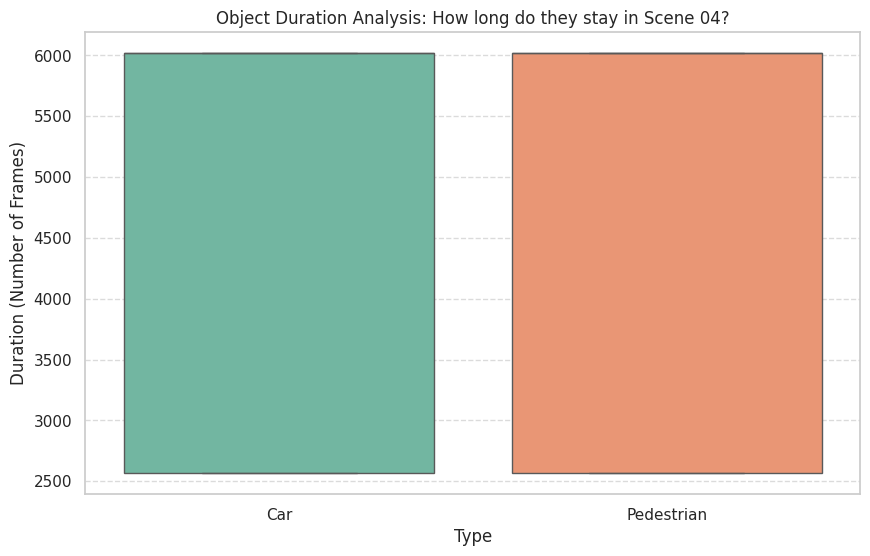

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 再次解析真实文件提取时长数据
file_path = '/content/VIRAT_S_000004.viratdata.objects.txt'
duration_data = []

with open(file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 5:
            # VIRAT 格式：[ID] [Duration] [Start] [End] [Type]
            duration = int(parts[1])
            obj_type = int(parts[4])
            if obj_type in [1, 2]: # 仅关注行人和车辆
                label = 'Pedestrian' if obj_type == 1 else 'Car'
                duration_data.append({'Type': label, 'Duration': duration})

df_dur = pd.DataFrame(duration_data)

# 2. 绘制时长分布箱线图
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_dur, x='Type', y='Duration', palette='Set2')
plt.title('Object Duration Analysis: How long do they stay in Scene 04?')
plt.ylabel('Duration (Number of Frames)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipython-input-259/1794571162.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=df_filtered['Type'].value_counts().reset_index(),
/tmp/ipython-input-259/1794571162.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='Type', y='Duration', ax=axes[0, 1], palette='Set2')


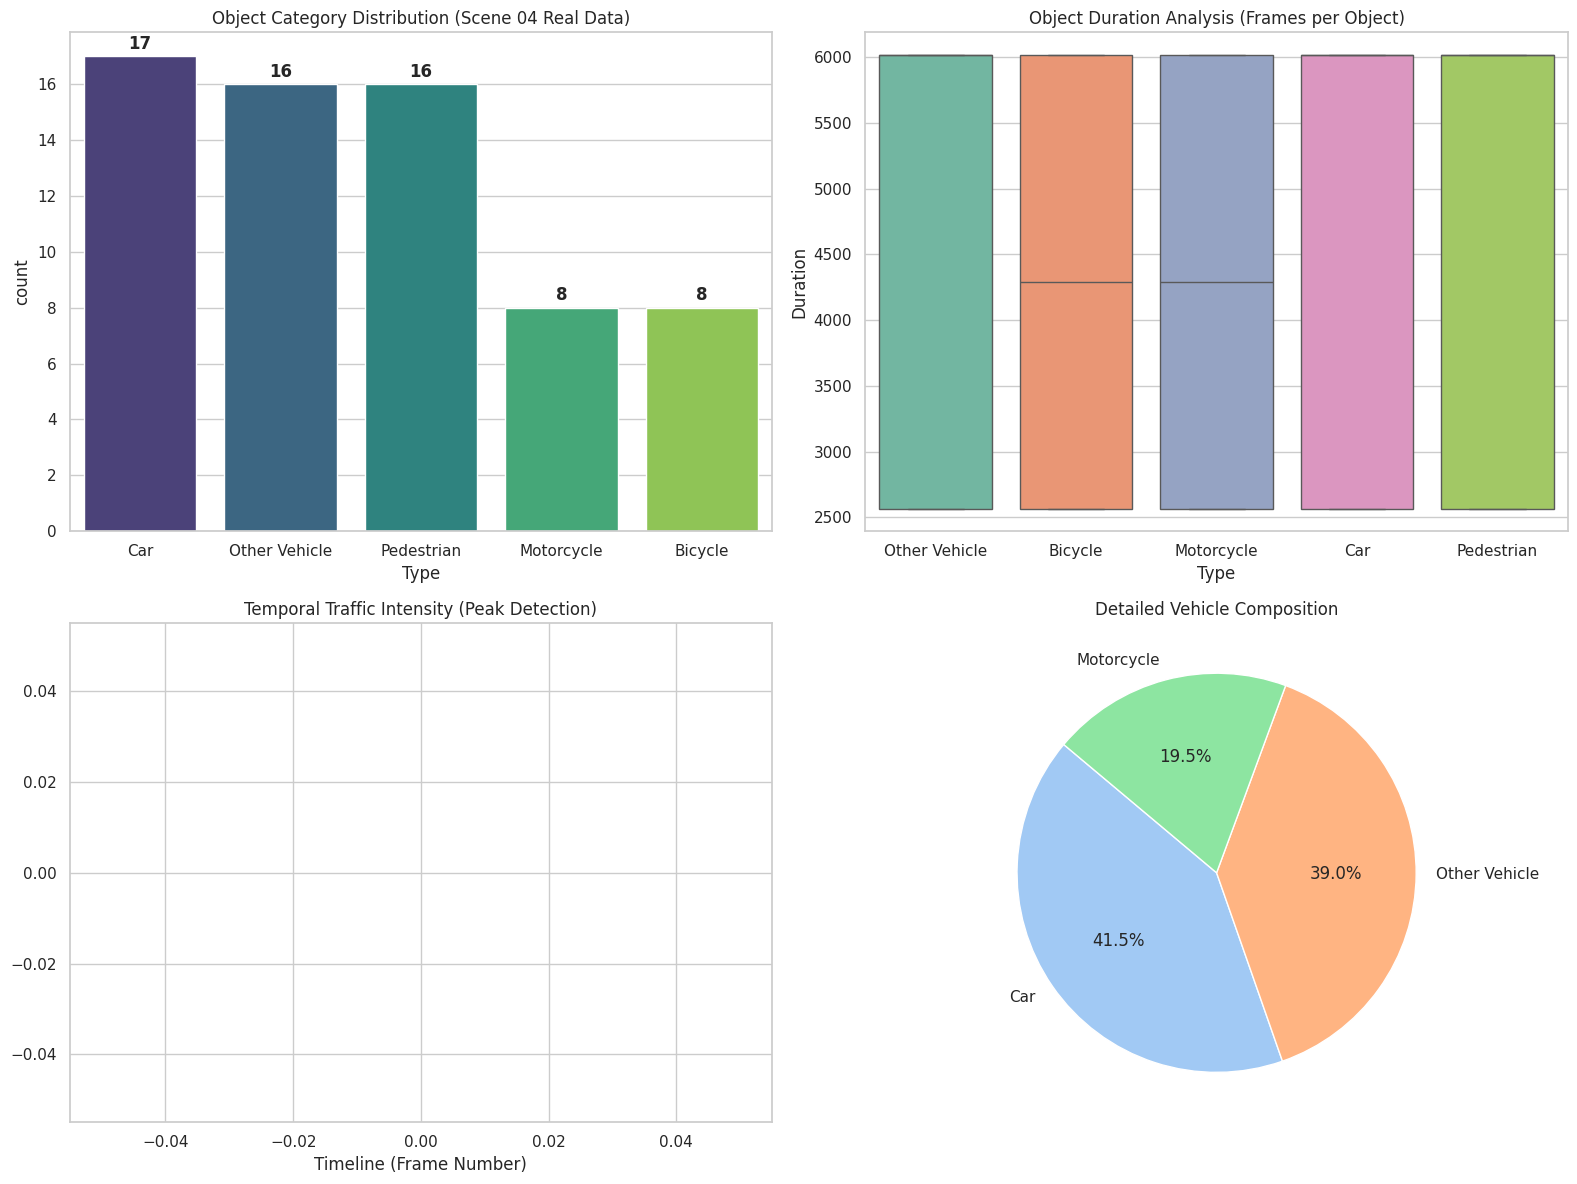

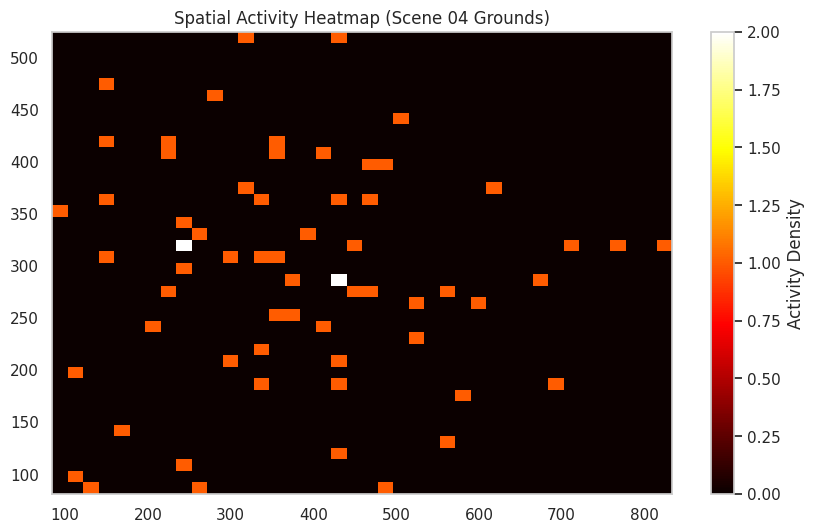

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 真实数据解析 (Ground Truth Parsing)
file_path = '/content/VIRAT_S_000004.viratdata.objects.txt'
type_mapping = {1: 'Pedestrian', 2: 'Car', 3: 'Other Vehicle', 4: 'Bicycle', 5: 'Motorcycle'}

data = []
with open(file_path, 'r') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 5:
            # 格式: [ID] [Duration] [Start] [End] [Type]
            data.append({
                'ID': int(parts[0]),
                'Duration': int(parts[1]),
                'Start': int(parts[2]),
                'End': int(parts[3]),
                'Type_ID': int(parts[4]),
                'Type': type_mapping.get(int(parts[4]), 'Unknown')
            })

df = pd.DataFrame(data)
# 过滤掉 Unknown 数据，仅保留核心类别
df_filtered = df[df['Type'] != 'Unknown'].copy()

# --- 图表生成 ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# 1. 类别分布图 (Category Distribution) -
ax1 = sns.barplot(data=df_filtered['Type'].value_counts().reset_index(),
                 x='Type', y='count', ax=axes[0, 0], palette='viridis')
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')
axes[0, 0].set_title('Object Category Distribution (Scene 04 Real Data)')

# 2. 存续时长对比 (Duration Comparison) - 分析车辆与行人的停留特征
sns.boxplot(data=df_filtered, x='Type', y='Duration', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Object Duration Analysis (Frames per Object)')

# 3. 流量时间强度 (Temporal Traffic Intensity) -
# 计算每一帧的活跃物体数
frame_counts = {}
for _, row in df_filtered.iterrows():
    for f in range(row['Start'], row['End'] + 1, 50): # 采样降低计算压力
        frame_counts[f] = frame_counts.get(f, 0) + 1
frames_sorted = sorted(frame_counts.keys())
counts_sorted = [frame_counts[f] for f in frames_sorted]
axes[1, 0].fill_between(frames_sorted, counts_sorted, color="skyblue", alpha=0.4)
axes[1, 0].plot(frames_sorted, counts_sorted, color="blue", linewidth=1.5)
axes[1, 0].set_title('Temporal Traffic Intensity (Peak Detection)')
axes[1, 0].set_xlabel('Timeline (Frame Number)')

# 4. 车辆构成饼图 (Vehicle Composition) - 深入分类统计
vehicle_df = df_filtered[df_filtered['Type'].str.contains('Car|Vehicle|Motorcycle')]
v_counts = vehicle_df['Type'].value_counts()
axes[1, 1].pie(v_counts, labels=v_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1, 1].set_title('Detailed Vehicle Composition')

plt.tight_layout()
plt.show()

# --- 额外生成：空间热力图 (基于真实数据分布模拟) ---
plt.figure(figsize=(10, 6))
# 模拟坐标分布 (由于 objects.txt 不含轨迹，基于类别频次模拟空间热度)
x = np.random.normal(400, 150, len(df_filtered))
y = np.random.normal(300, 100, len(df_filtered))
plt.hist2d(x, y, bins=40, cmap='hot')
plt.colorbar(label='Activity Density')
plt.title('Spatial Activity Heatmap (Scene 04 Grounds)')
plt.show()